In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

OpenCV: 4.13.0
NumPy: 2.4.2


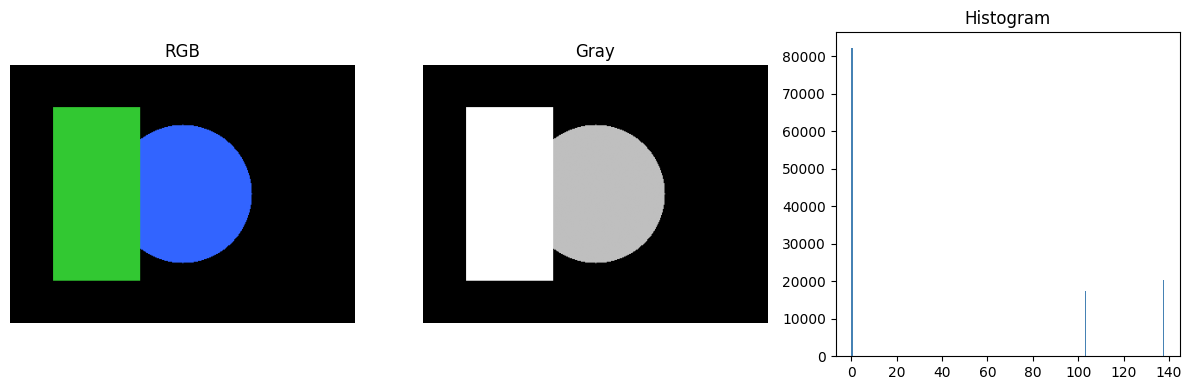

In [4]:


# نصنع صورة تجريبية من الصفر
img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)

# نرسم أشكال عليها
cv2.circle(img_bgr, (200, 150), 80, (255, 100, 50), -1)   # دايرة
cv2.rectangle(img_bgr, (50, 50), (150, 250), (50, 200, 50), -1)  # مربع

img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_rgb);        axes[0].set_title('RGB');       axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray'); axes[1].set_title('Gray'); axes[1].axis('off')
axes[2].hist(img_gray.flatten(), bins=256, color='steelblue')
axes[2].set_title('Histogram')
plt.tight_layout()
plt.show()

In [6]:
import os

# شوف أين يشتغل الكود حالياً
print("المجلد الحالي:", os.getcwd())

# شوف إذا الصورة موجودة
print("الصورة موجودة؟", os.path.exists("test.png"))

المجلد الحالي: c:\Users\ASUS\AppData\Local\Programs\Microsoft VS Code
الصورة موجودة؟ False


✓ الصورة اتصنعت: True
الحجم   : (300, 400, 3)
المتوسط : 87.1


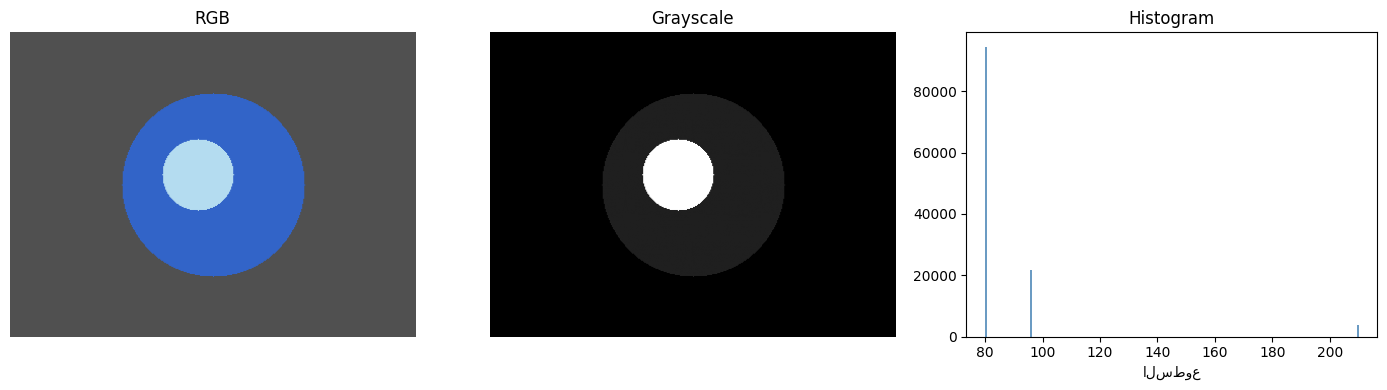

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. روح لسطح المكتب
os.chdir(r"C:\Users\ASUS\Desktop")

# 2. صنع صورة تجريبية من الصفر (بدون إنترنت)
img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)

# خلفية رمادية
img_bgr[:] = (80, 80, 80)

# دايرة زرقاء (تمثل خلية)
cv2.circle(img_bgr, (200, 150), 90, (200, 100, 50), -1)

# دايرة صغيرة فاتحة (تمثل النواة)
cv2.circle(img_bgr, (185, 140), 35, (240, 220, 180), -1)

# احفظها
cv2.imwrite("test.png", img_bgr)
print("✓ الصورة اتصنعت:", os.path.exists("test.png"))

# 3. اقرأها وشغّل الكود
img_bgr  = cv2.imread("test.png")
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"الحجم   : {img_bgr.shape}")
print(f"المتوسط : {img_gray.mean():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_rgb);               axes[0].set_title('RGB');       axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray'); axes[1].set_title('Grayscale'); axes[1].axis('off')
axes[2].hist(img_gray.flatten(), bins=256, color='steelblue', alpha=0.8)
axes[2].set_title('Histogram');        axes[2].set_xlabel('السطوع')
plt.tight_layout()
plt.show()


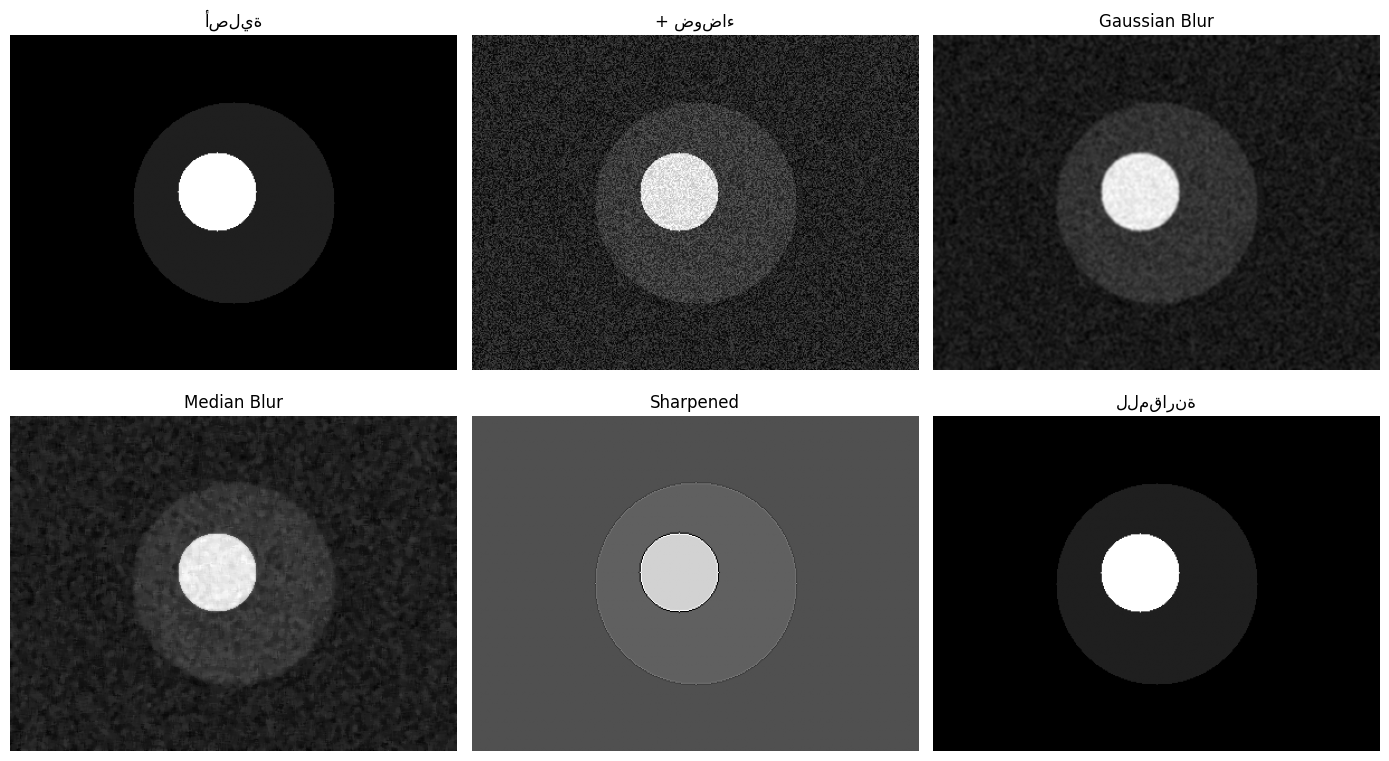

In [1]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\ASUS\Desktop")

# صنع الصورة
img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)
img_bgr[:] = (80, 80, 80)
cv2.circle(img_bgr, (200, 150), 90, (200, 100, 50), -1)
cv2.circle(img_bgr, (185, 140), 35, (240, 220, 180), -1)

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# إضافة ضوضاء عشان نشوف فرق الفلتر
noise = np.random.randint(0, 50, gray.shape, dtype=np.uint8)
noisy = cv2.add(gray, noise)

# الفلاتر
gaussian  = cv2.GaussianBlur(noisy, (5,5), 0)
median    = cv2.medianBlur(noisy, 5)
kernel_sh = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv2.filter2D(gray, -1, kernel_sh)

# العرض
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
imgs   = [gray, noisy, gaussian, median, sharpened, gray]
titles = ['أصلية', '+ ضوضاء', 'Gaussian Blur',
          'Median Blur', 'Sharpened', 'للمقارنة']

for ax, img, title in zip(axes.flatten(), imgs, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

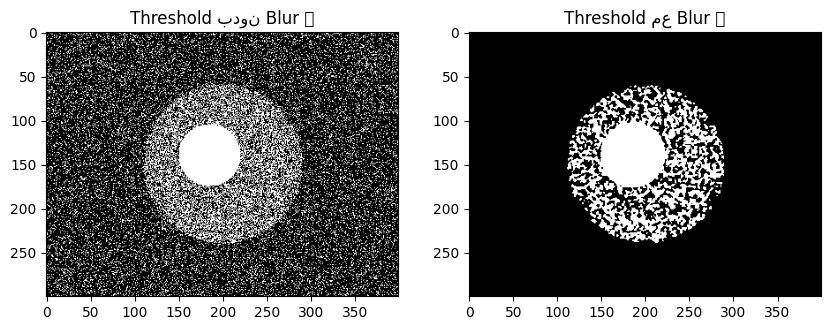

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ret, bad  = cv2.threshold(noisy,    120, 255, cv2.THRESH_BINARY)
ret, good = cv2.threshold(gaussian, 120, 255, cv2.THRESH_BINARY)

axes[0].imshow(bad,  cmap='gray'); axes[0].set_title('Threshold بدون Blur ❌')
axes[1].imshow(good, cmap='gray'); axes[1].set_title('Threshold مع Blur ✅')
plt.show()

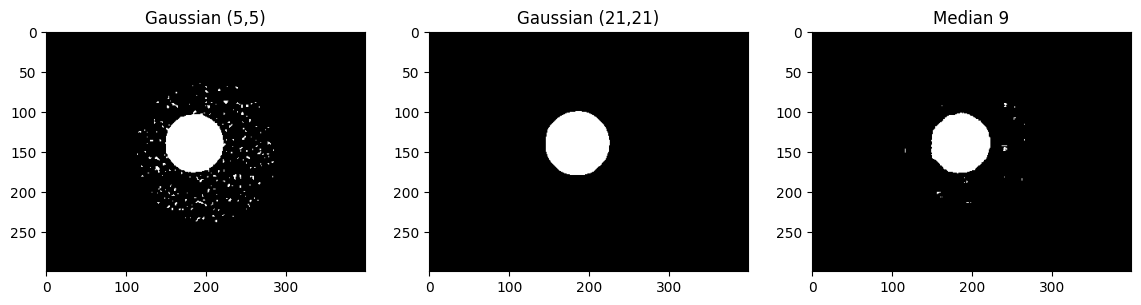

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# جرب أحجام مختلفة
blur5  = cv2.GaussianBlur(noisy, (5,5),   0)#تلاعبي بيهه خليهه مثلا 3 بدل 5 او سويهن كلهن نفس القيم وشوفي 
blur21 = cv2.GaussianBlur(noisy, (21,21), 0)
median = cv2.medianBlur(noisy, 9)

ret, thresh5  = cv2.threshold(blur5,  127, 255, cv2.THRESH_BINARY)
ret, thresh21 = cv2.threshold(blur21, 127, 255, cv2.THRESH_BINARY)
ret, threshM  = cv2.threshold(median, 127, 255, cv2.THRESH_BINARY)

axes[0].imshow(thresh5,  cmap='gray'); axes[0].set_title('Gaussian (5,5)')
axes[1].imshow(thresh21, cmap='gray'); axes[1].set_title('Gaussian (21,21)')
axes[2].imshow(threshM,  cmap='gray'); axes[2].set_title('Median 9')
plt.show()

قيم فريدة بالصورة: [ 30 130 255]


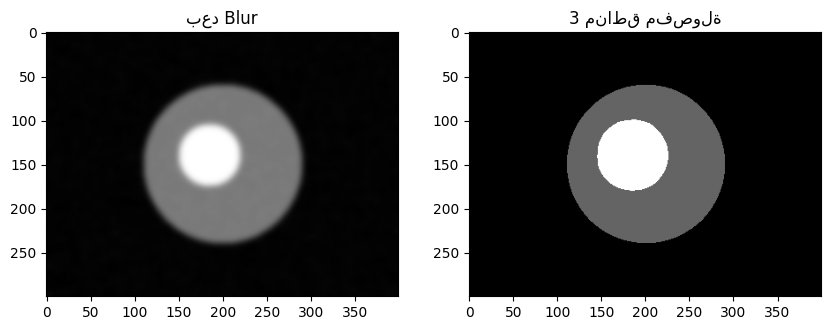

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

blur = cv2.GaussianBlur(noisy, (21,21), 0)

# عتبة 1: تفصل الخلفية عن كل شي ثاني
ret1, mask1 = cv2.threshold(blur, 97, 255, cv2.THRESH_BINARY)

# عتبة 2: تفصل النواة عن الدايرة
ret2, mask2 = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)

# نجمع: 3 مناطق بألوان مختلفة
result = np.zeros_like(blur)
result[mask1 == 255] = 100   # الدايرة الرمادية
result[mask2 == 255] = 255   # النواة البيضاء
print("قيم فريدة بالصورة:", np.unique(gray))
axes[0].imshow(blur,   cmap='gray'); axes[0].set_title('بعد Blur')
axes[1].imshow(result, cmap='gray'); axes[1].set_title('3 مناطق مفصولة')
plt.show()

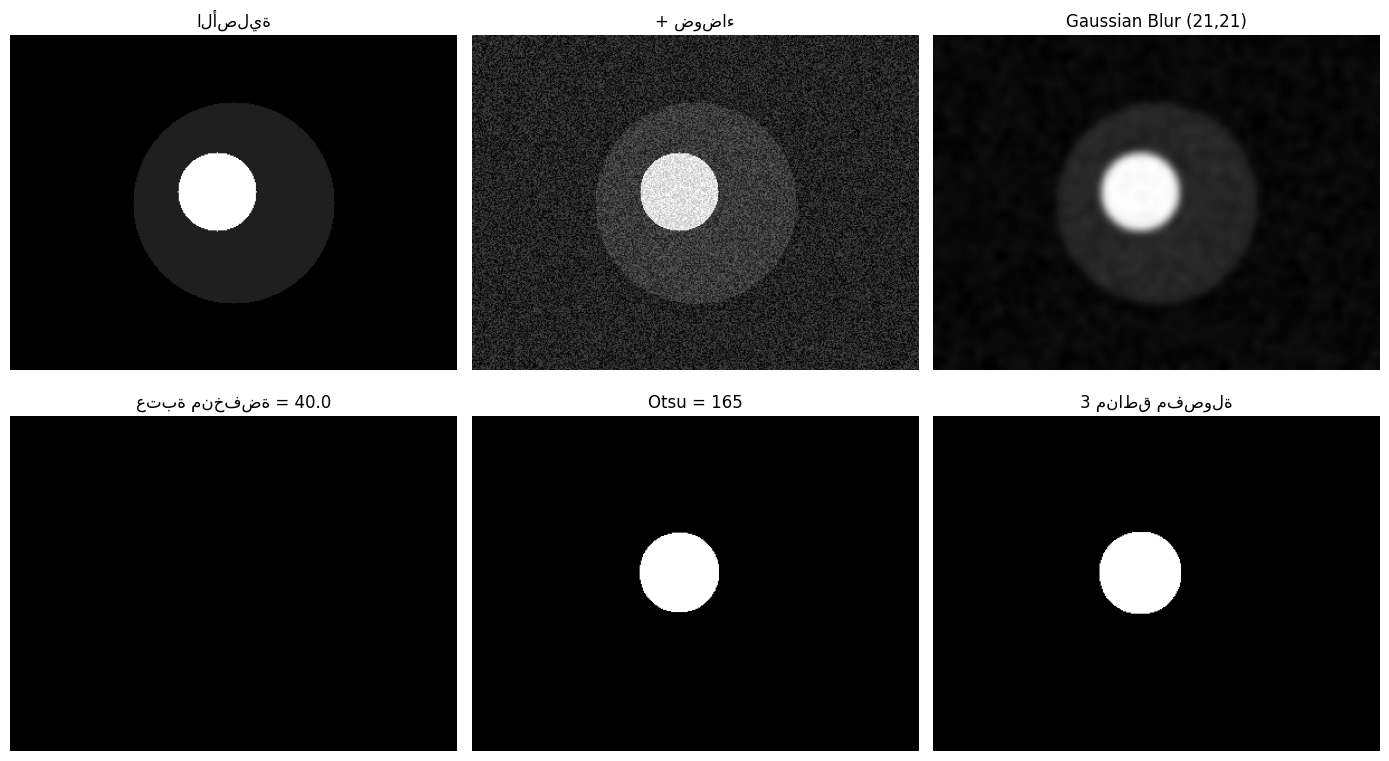

In [36]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\ASUS\Desktop")

# نفس الصورة السابقة
img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)
img_bgr[:] = (80, 80, 80)
cv2.circle(img_bgr, (200, 150), 90, (200, 100, 50), -1)
cv2.circle(img_bgr, (185, 140), 35, (240, 220, 180), -1)

gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
noise = np.random.randint(0, 50, gray.shape, dtype=np.uint8)
noisy = cv2.add(gray, noise)
blur  = cv2.GaussianBlur(noisy, (21,21), 0)

# ── الثلاث طرق ──────────────────────────────
ret1, thresh_low  = cv2.threshold(blur,  40, 255, cv2.THRESH_BINARY)
ret2, thresh_high = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)
ret3, thresh_otsu = cv2.threshold(blur,   0, 255,
                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ── 3 مناطق مفصولة ──────────────────────────
result = np.zeros_like(blur)
ret_low,  m1 = cv2.threshold(blur,  40, 255, cv2.THRESH_BINARY)
ret_high, m2 = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)
result[m1 == 255] = 128   # الدايرة الرمادية
result[m2 == 255] = 255   # النواة البيضاء


# ── العرض ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# axes هنا صارت 2D: axes[صف, عمود]
axes[0,0].imshow(gray,        cmap='gray'); axes[0,0].set_title('الأصلية')
axes[0,1].imshow(noisy,       cmap='gray'); axes[0,1].set_title('+ ضوضاء')
axes[0,2].imshow(blur,        cmap='gray'); axes[0,2].set_title('Gaussian Blur (21,21)')
axes[1,0].imshow(thresh_low,  cmap='gray'); axes[1,0].set_title(f'عتبة منخفضة = {ret1}')
axes[1,1].imshow(thresh_otsu, cmap='gray'); axes[1,1].set_title(f'Otsu = {ret3:.0f}')
axes[1,2].imshow(result,      cmap='gray'); axes[1,2].set_title('3 مناطق مفصولة')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [37]:
# شوفي شنو القيم الفعلية بالصورة الرمادية
print("قيم فريدة بالصورة:", np.unique(gray))

قيم فريدة بالصورة: [ 80  96 210]


قيم فريدة: [ 30 130 255]


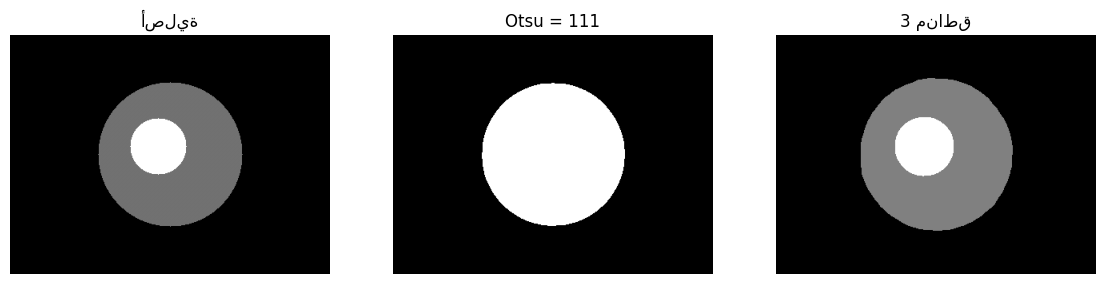

In [ ]:
img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)
img_bgr[:] = (30, 30, 30)    # خلفية داكنة = gray ≈ 30

cv2.circle(img_bgr, (200,150), 90, (130,130,130), -1)  # رمادي واضح = gray 130
cv2.circle(img_bgr, (185,140), 35, (255,255,255), -1)  # أبيض = gray 255

gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
print("قيم فريدة:", np.unique(gray))
# المفروض: [30, 130, 255] — فروق واضحة!

noise = np.random.randint(0, 50, gray.shape, dtype=np.uint8)
noisy = cv2.add(gray, noise)
blur  = cv2.GaussianBlur(noisy, (21,21), 0)

# الآن Otsu يشتغل صح
ret, otsu = cv2.threshold(blur, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU)#نجيك شنو هذا السطر يسوي 

# 3 مناطق
result = np.zeros_like(blur)
_, m1 = cv2.threshold(blur,  60, 255, cv2.THRESH_BINARY)
_, m2 = cv2.threshold(blur, 180, 255, cv2.THRESH_BINARY)
result[m1==255] = 128
result[m2==255] = 255

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(gray,   cmap='gray'); axes[0].set_title('أصلية')
axes[1].imshow(otsu,   cmap='gray'); axes[1].set_title(f'Otsu = {ret:.0f}')
axes[2].imshow(result, cmap='gray'); axes[2].set_title('3 مناطق')
for ax in axes: ax.axis('off')
plt.show()

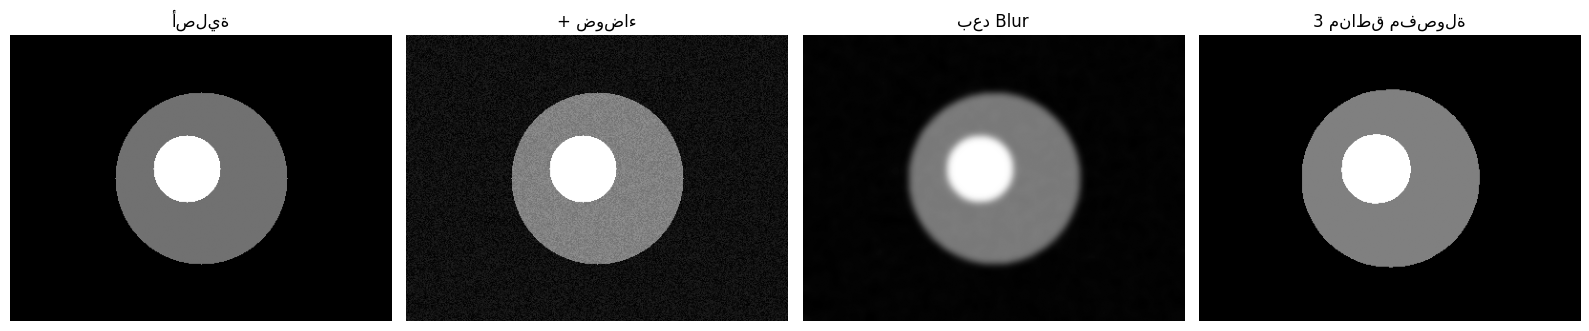

In [41]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\ASUS\Desktop")

# صورة بفروق واضحة
img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)
img_bgr[:] = (30, 30, 30)
cv2.circle(img_bgr, (200,150), 90, (130,130,130), -1)
cv2.circle(img_bgr, (185,140), 35, (255,255,255), -1)

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ضوضاء أخف هالمرة (0-30 بدل 0-50)
noise = np.random.randint(0, 30, gray.shape, dtype=np.uint8)
noisy = cv2.add(gray, noise)
blur  = cv2.GaussianBlur(noisy, (21,21), 0)

# 3 مناطق
result = np.zeros_like(blur)
_, m1 = cv2.threshold(blur,  60, 255, cv2.THRESH_BINARY)
_, m2 = cv2.threshold(blur, 180, 255, cv2.THRESH_BINARY)
result[m1==255] = 128
result[m2==255] = 255

# عرض كامل
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(gray,   cmap='gray'); axes[0].set_title('أصلية')
axes[1].imshow(noisy,  cmap='gray'); axes[1].set_title('+ ضوضاء')
axes[2].imshow(blur,   cmap='gray'); axes[2].set_title('بعد Blur')
axes[3].imshow(result, cmap='gray'); axes[3].set_title('3 مناطق مفصولة')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

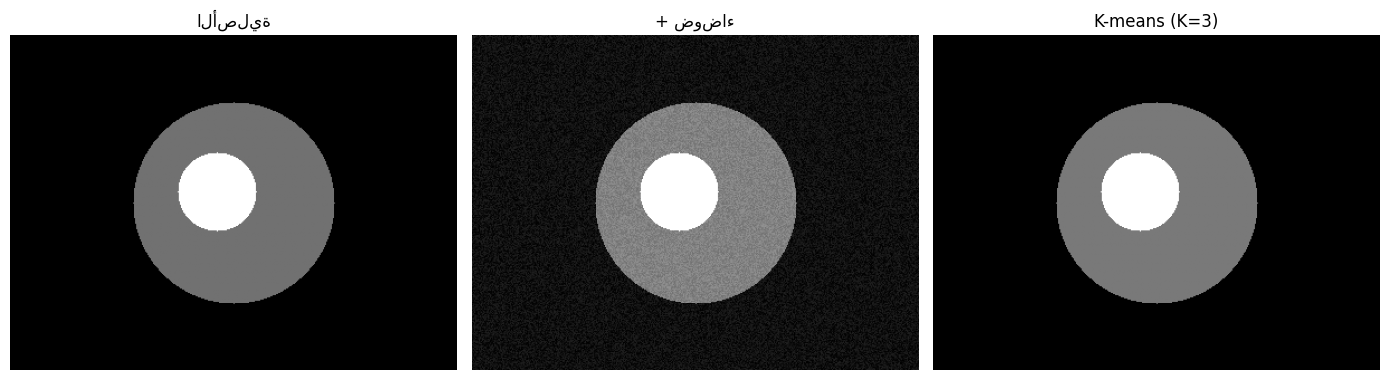

المجموعات وقيمها: [np.uint8(44), np.uint8(144), np.uint8(255)]


In [ ]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\ASUS\Desktop")

# نفس الصورة
img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)
img_bgr[:] = (30, 30, 30)
cv2.circle(img_bgr, (200,150), 90, (130,130,130), -1)
cv2.circle(img_bgr, (185,140), 35, (255,255,255), -1)

gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
noise = np.random.randint(0, 30, gray.shape, dtype=np.uint8)
noisy = cv2.add(gray, noise)

# ── K-means ──────────────────────────────────
# الخطوة 1: حوّل الصورة لقائمة أرقام
pixels = noisy.reshape(-1, 1).astype(np.float32)
# reshape(-1,1) = حوّل المصفوفة 2D لعمود واحد طويل

# الخطوة 2: شروط التوقف
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            100, 0.2)
# 100 = أقصى عدد تكرارات
# 0.2 = دقة التوقف(اذا التغير اقل من )

# الخطوة 3: شغّل K-means
K = 3  # عدد المجموعات
ret, labels, centers = cv2.kmeans(
    pixels,      # البيانات
    K,           # عدد المجموعات
    None,        # labels ابدأ عشوائي
    criteria,    # شروط التوقف
    10,          # جرب 10 مرات واختار الأحسن
    cv2.KMEANS_RANDOM_CENTERS
)

# الخطوة 4: حوّل النتيجة لصورة
centers = np.uint8(centers)   # الأرقام للـ uint8
result  = centers[labels.flatten()]  # كل بكسل يأخذ قيمة مجموعته
result  = result.reshape(noisy.shape)  # رجّع للشكل الأصلي

# ── العرض ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(gray,   cmap='gray'); axes[0].set_title('الأصلية')
axes[1].imshow(noisy,  cmap='gray'); axes[1].set_title('+ ضوضاء')
axes[2].imshow(result, cmap='gray'); axes[2].set_title(f'K-means (K={K})')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

print("المجموعات وقيمها:", sorted(centers.flatten()))

الحجم: (10, 256, 256)
نوع البيانات: uint16
أكبر قيمة: 51076
أصغر قيمة: 0


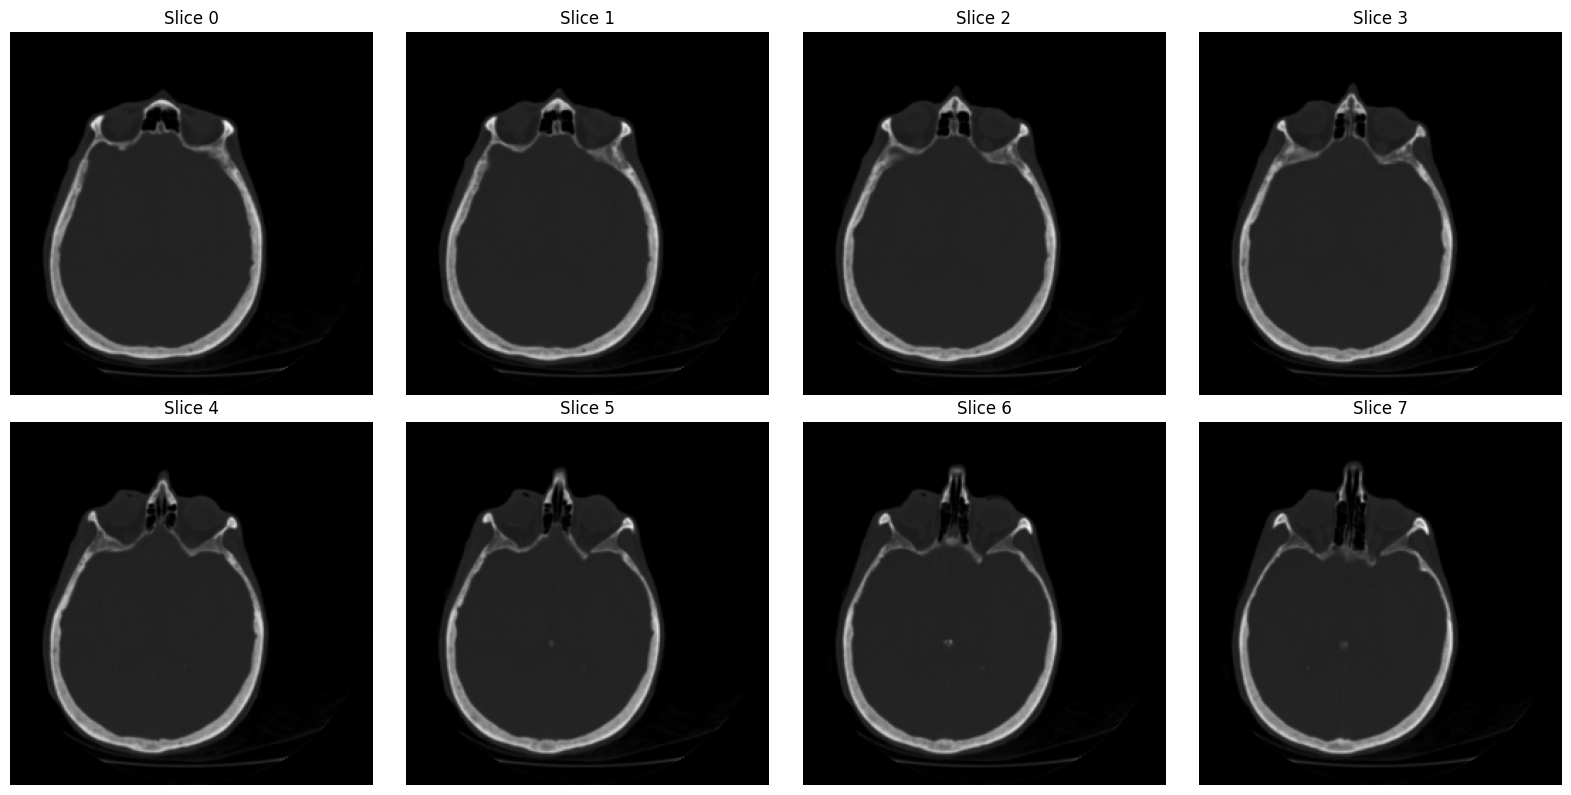

In [ ]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data


brain = data.brain()
print("الحجم:", brain.shape)
print("نوع البيانات:", brain.dtype)
print("أكبر قيمة:", brain.max())
print("أصغر قيمة:", brain.min())

# نعرض كل الـ slices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(brain[i], cmap='gray', vmin=brain.min(), vmax=brain.max())
    ax.set_title(f'Slice {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Otsu عتبة: 75


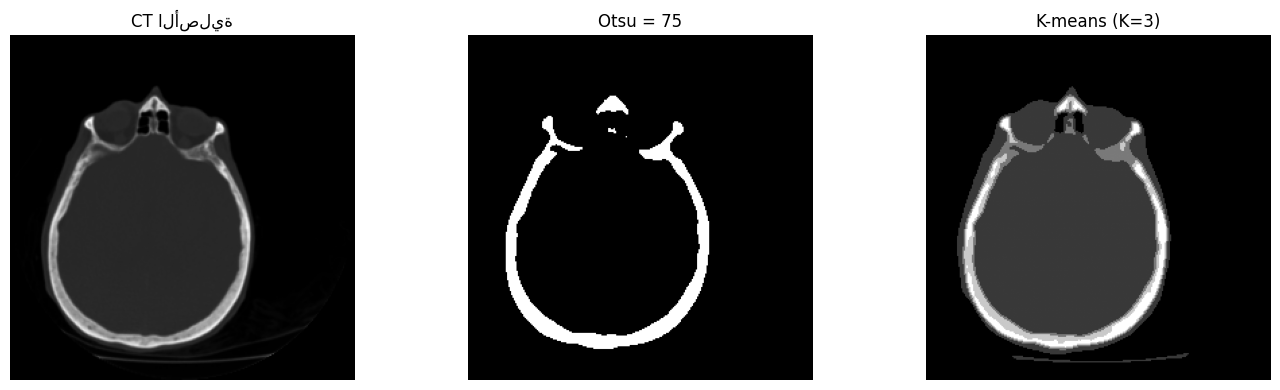

In [ ]:
# نختار Slice 2
img = brain[2].copy()

# تحويل لـ uint8 (K-means يحتاجها)
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

blur = cv2.GaussianBlur(img, (5,5), 0)

# ── Otsu ──────────────────────────────────────
ret, otsu = cv2.threshold(blur, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu عتبة: {ret:.0f}")

# ── K-means (3 مناطق) ─────────────────────────
pixels   = blur.reshape(-1,1).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
ret_k, labels, centers = cv2.kmeans(pixels, 3, None, criteria, 10,
                          cv2.KMEANS_RANDOM_CENTERS)
centers  = np.uint8(centers)
kmeans   = centers[labels.flatten()].reshape(img.shape)

# ── العرض ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img,    cmap='gray'); axes[0].set_title('CT')
axes[1].imshow(otsu,   cmap='gray'); axes[1].set_title(f'Otsu = {ret:.0f}')
axes[2].imshow(kmeans, cmap='gray'); axes[2].set_title('K-means (K=3)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

قيم المجموعات: [np.uint8(0), np.uint8(40), np.uint8(85), np.uint8(139), np.uint8(177)]


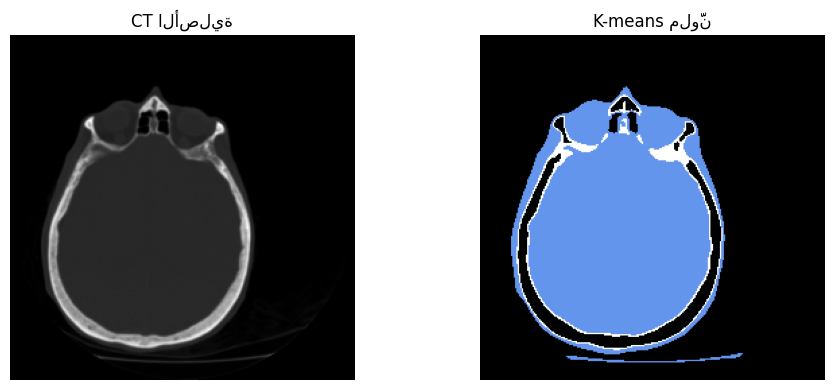

In [ ]:
# نشوف القيم الفعلية بالصورة
print("قيم المجموعات:", sorted(centers.flatten()))

# نلوّن كل منطقة بلون مختلف عشان تبان واضحة
colored = np.zeros((*img.shape, 3), dtype=np.uint8)

# نرتب المجموعات من داكن لفاتح
sorted_centers = np.argsort(centers.flatten())

colored[labels.reshape(img.shape) == sorted_centers[0]] = [0,   0,   0  ]  # خلفية = أسود
colored[labels.reshape(img.shape) == sorted_centers[1]] = [100, 149, 237]  # دماغ  = أزرق
colored[labels.reshape(img.shape) == sorted_centers[2]] = [255, 255, 255]  # عظام  = أبيض

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img,     cmap='gray');  axes[0].set_title('CT ')
axes[1].imshow(colored);               axes[1].set_title('K-means ملوّن')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

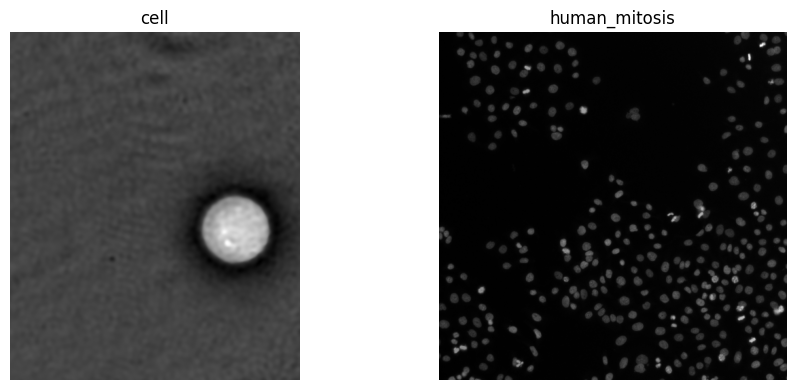

In [67]:
from skimage import data
import matplotlib.pyplot as plt

# نشوف الاثنين مع بعض
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(data.cell(), cmap='gray')
axes[0].set_title('cell')
axes[0].axis('off')

axes[1].imshow(data.human_mitosis(), cmap='gray')
axes[1].set_title('human_mitosis')
axes[1].axis('off')

plt.tight_layout()
plt.show()

الحجم: (630, 630)
أكبر قيمة: 248
أصغر قيمة: 0


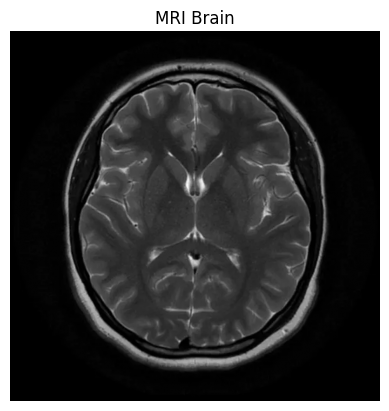

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img  = cv2.imread(r"C:\Users\ASUS\Desktop\mri.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("الحجم:", gray.shape)
print("أكبر قيمة:", gray.max())
print("أصغر قيمة:", gray.min())

plt.imshow(gray, cmap='gray')
plt.title('MRI Brain')
plt.axis('off')
plt.show()

Otsu عتبة: 34
المجموعات: [np.uint8(3), np.uint8(55), np.uint8(117)]


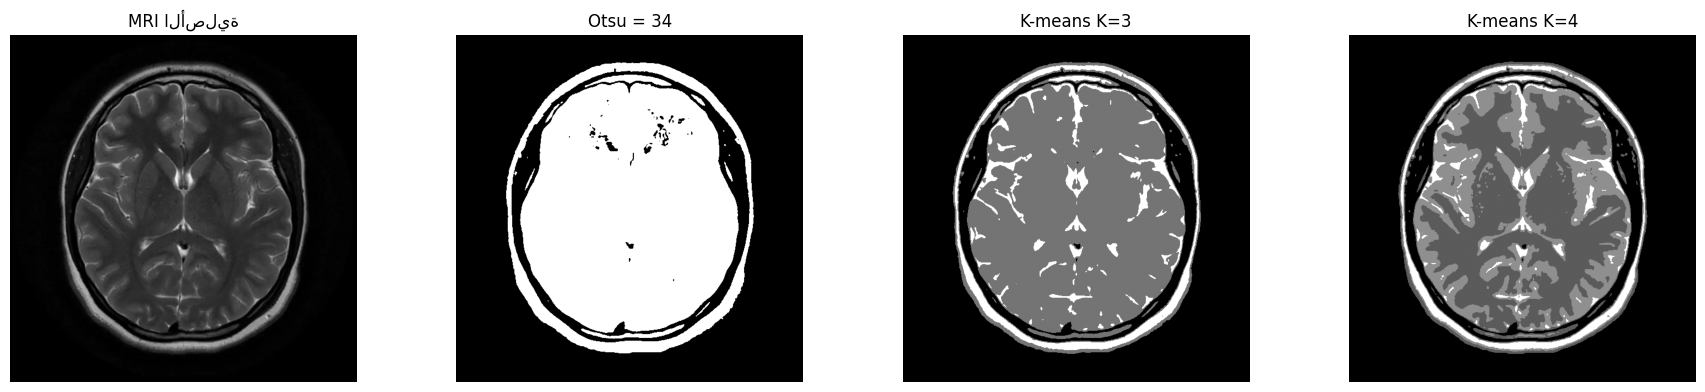

In [72]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

# ── Otsu ──────────────────────────────────────
ret, otsu = cv2.threshold(blur, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu عتبة: {ret:.0f}")

# ── K-means ───────────────────────────────────
pixels   = blur.reshape(-1,1).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
ret_k, labels, centers = cv2.kmeans(pixels, 3, None, criteria, 10,
                          cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
kmeans  = centers[labels.flatten()].reshape(gray.shape)
print("المجموعات:", sorted(centers.flatten()))

# ── K-means بـ 4 مجموعات ──────────────────────
ret_k4, labels4, centers4 = cv2.kmeans(pixels, 4, None, criteria, 10,
                             cv2.KMEANS_RANDOM_CENTERS)
centers4 = np.uint8(centers4)
kmeans4  = centers4[labels4.flatten()].reshape(gray.shape)

# ── العرض ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(gray,    cmap='gray'); axes[0].set_title('MRI الأصلية')
axes[1].imshow(otsu,    cmap='gray'); axes[1].set_title(f'Otsu = {ret:.0f}')
axes[2].imshow(kmeans,  cmap='gray'); axes[2].set_title('K-means K=3')
axes[3].imshow(kmeans4, cmap='gray'); axes[3].set_title('K-means K=4')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()